# Generate Werner states

## Method1

Ref: https://github.com/MMarianus/quantum-werner_state

Generating a Werner State from a composite quantum system:

 [i]- Initial system preparation:
System State:


<IPython.core.display.Latex object>


 Density Matrix:


<IPython.core.display.Latex object>


 Circuit:


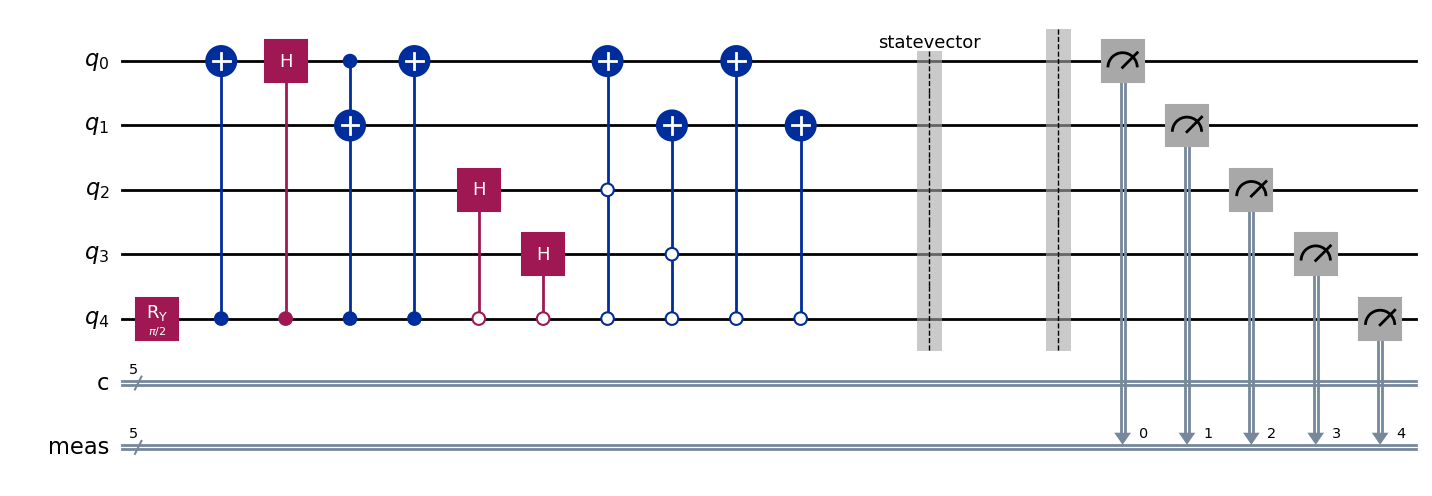


 [i]- Obtaining a Werner State:


<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
import qiskit.quantum_info as qi
import numpy as np

def werner_state():
  print("Generating a Werner State from a composite quantum system:")
  qc = QuantumCircuit(5,5)
  
  # Werner state: ρ = λ|Φ-⟩⟨Φ-| + (1-λ)I/4
  #lamb = 0 -> Identity
  #lamb = 1 -> Phi-
  #lamb = 0.5 -> P + I
  lamb = 0.5
  rot = 2 * np.arcsin(np.sqrt(lamb))
  qc.ry(rot, 4)
  qc.cx(4,0)
  qc.ch(4,0)
  qc.ccx(4,0,1)
  qc.cx(4,0)
  qc.ch(4, [2,3], ctrl_state=0)
  qc.ccx(4, 2,0, ctrl_state=0)
  qc.ccx(4, 3,1, ctrl_state=0)
  qc.cx(4,[0,1], ctrl_state=0)

  qc.save_statevector()
  qc.measure_all()

  backend = Aer.get_backend('qasm_simulator')
  transpiled_qc = transpile(qc, backend)
  results = backend.run(transpiled_qc, shots=1000).result()

  state_vector = results.get_statevector()
  print("\n [i]- Initial system preparation:")
  print("System State:")
  display(state_vector.draw('latex'))

  dm = qi.DensityMatrix(state_vector)
  print("\n Density Matrix:")
  display(dm.draw('latex'))

  print("\n Circuit:")
  display(qc.draw(output="mpl"))

  print("\n [i]- Obtaining a Werner State:")
  traced_over_qubits = [2,3,4]
  ws_density_matrix = qi.partial_trace(results.get_statevector(), traced_over_qubits)
  display(ws_density_matrix.draw('latex'))

werner_state()

## Method2

Ref: https://arxiv.org/pdf/1912.06105

Generating a Werner State from a composite quantum system:

 [i]- Initial system preparation:
System State:


<IPython.core.display.Latex object>


 Density Matrix:


<IPython.core.display.Latex object>


 Circuit:


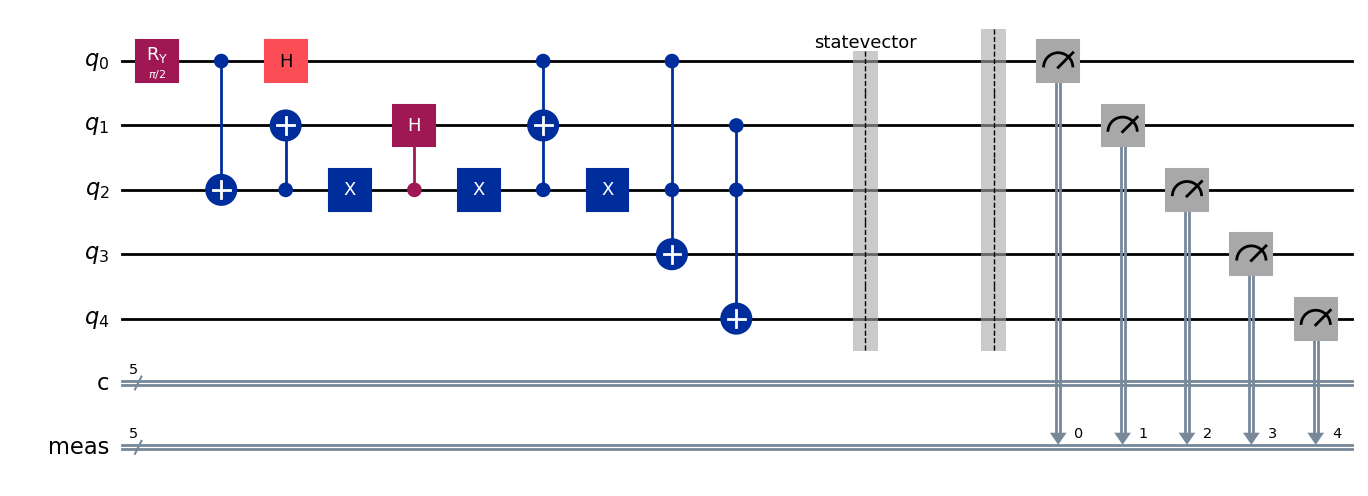


 [i]- Obtaining a Werner State:


<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
import qiskit.quantum_info as qi
import numpy as np

def werner_state2():
  print("Generating a Werner State from a composite quantum system:")
  qc = QuantumCircuit(5,5)
  
  # Werner state: ρ = p|Φ-⟩⟨Φ-| + (1-p)I/4

  p = 0.5
  rot = 2 * np.arcsin(np.sqrt(p))
  qc.ry(rot, 0)
  qc.cx(0,2)
  qc.h(0)
  qc.cx(2,1)
  qc.x(2)
  qc.ch(2,1)
  qc.x(2)
  qc.ccx(0,2,1)
  qc.x(2)
  qc.ccx(0,2,3)
  qc.ccx(1,2,4)

  qc.save_statevector()
  qc.measure_all()

  backend = Aer.get_backend('qasm_simulator')
  transpiled_qc = transpile(qc, backend)
  results = backend.run(transpiled_qc, shots=1000).result()

  state_vector = results.get_statevector()
  print("\n [i]- Initial system preparation:")
  print("System State:")
  display(state_vector.draw('latex'))

  dm = qi.DensityMatrix(state_vector)
  print("\n Density Matrix:")
  display(dm.draw('latex'))

  print("\n Circuit:")
  display(qc.draw(output="mpl"))

  print("\n [i]- Obtaining a Werner State:")
  traced_over_qubits = [2,3,4]
  ws_density_matrix = qi.partial_trace(results.get_statevector(), traced_over_qubits)
  display(ws_density_matrix.draw('latex'))

werner_state2()

# QELM

Train MSE: 0.000000
Test  MSE: 0.000000
Test  R² : 1.0000


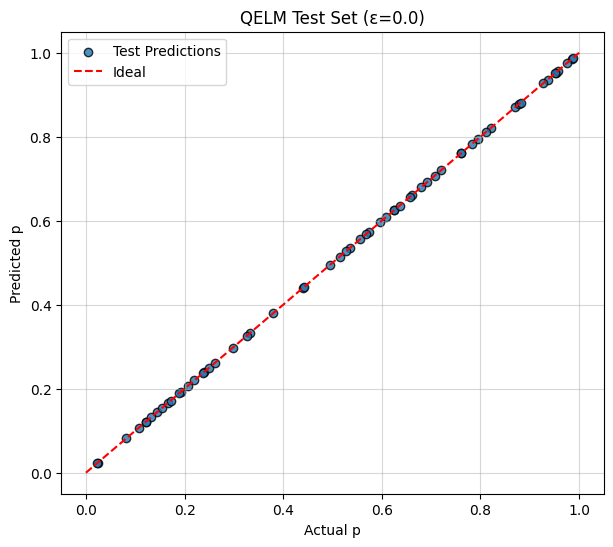

Train MSE: 0.003562
Test  MSE: 0.002819
Test  R² : 0.9680


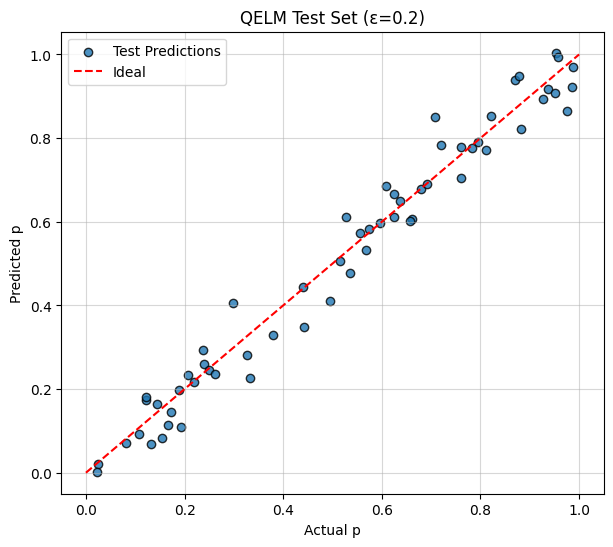

Train MSE: 0.030845
Test  MSE: 0.023013
Test  R² : 0.7391


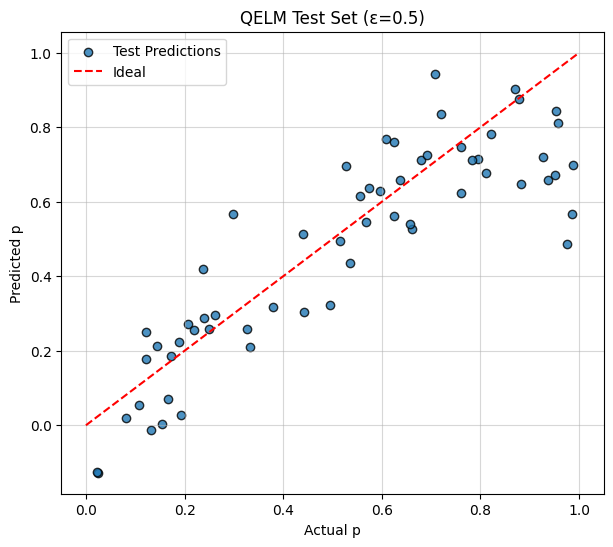

Train MSE: 0.151900
Test  MSE: 0.163874
Test  R² : -0.8580


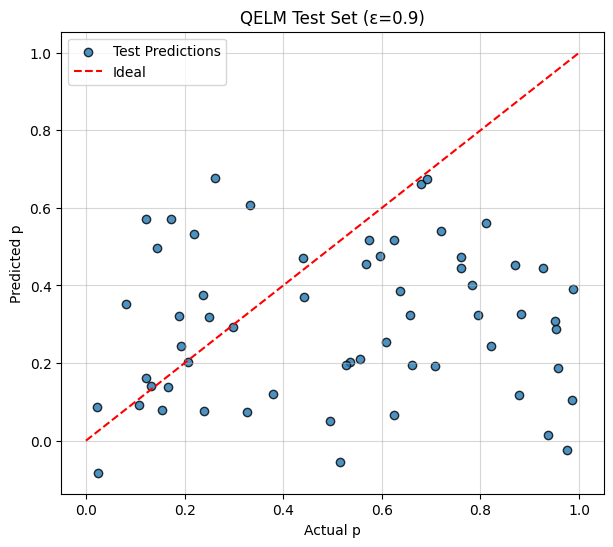

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
import warnings
from scipy.sparse import SparseEfficiencyWarning

warnings.filterwarnings(
    "ignore",
    category=SparseEfficiencyWarning
)

# -------------------------------------------------
# 1. State Preparation Circuit
# -------------------------------------------------
def prepare_state_circuit(p, n=5):
    qc = QuantumCircuit(n)

    rot = 2 * np.arcsin(np.sqrt(p))

    qc.ry(rot, 0)
    qc.cx(0, 2)
    qc.h(0)
    qc.cx(2, 1)
    qc.x(2)
    qc.ch(2, 1)
    qc.x(2)
    qc.ccx(0, 2, 1)
    qc.x(2)
    qc.ccx(0, 2, 3)
    qc.ccx(1, 2, 4)

    return qc

# -------------------------------------------------
# 2. Hamiltonian
# -------------------------------------------------
def build_hamiltonian(J_matrix, h_field, n):
    paulis = []
    coeffs = []

    for i in range(n):
        for j in range(i + 1, n):
            label = ['I'] * n
            label[i] = 'X'
            label[j] = 'X'
            paulis.append(''.join(label))
            coeffs.append(J_matrix[i, j])

    for i in range(n):
        label = ['I'] * n
        label[i] = 'Z'
        paulis.append(''.join(label))
        coeffs.append(h_field)

    return SparsePauliOp(paulis, coeffs)

# -------------------------------------------------
# 3. Time Evolution
# -------------------------------------------------
def time_evolution_circuit(H_op, dt):
    trotter = LieTrotter(reps=1)
    return PauliEvolutionGate(H_op, time=dt, synthesis=trotter)

# -------------------------------------------------
# 4. Werner Noise
# -------------------------------------------------

def random_density_matrix(n):
    dim = 2 ** n
    G = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
    rho = G @ G.conj().T
    rho /= np.trace(rho)
    return DensityMatrix(rho)

def apply_werner_noise(rho_ideal, epsilon, n):
    r_k = random_density_matrix(n)
    return (1 - epsilon) * rho_ideal + epsilon * r_k

# -------------------------------------------------
# 5. ⟨Zi⟩ Measurements
# -------------------------------------------------
def measure_Z_expectations_density(rho, n):
    values = []
    for i in range(n):
        label = ['I'] * n
        label[i] = 'Z'
        Zi = SparsePauliOp(''.join(label))
        values.append(np.real(rho.expectation_value(Zi)))
    return values

# -------------------------------------------------
# 6. Parameters
# -------------------------------------------------
N_QUBITS = 5
H_FIELD = 0.1
DT = 2.0
NUM_SAMPLES = 200
TRAIN_RATIO = 0.7

for EPSILON in [0.0, 0.2, 0.5, 0.9]:
    np.random.seed(42)
    # -------------------------------------------------
    # 7. Build Hamiltonian
    # -------------------------------------------------
    J_matrix = np.random.uniform(-0.5, 0.5, (N_QUBITS, N_QUBITS))
    H_op = build_hamiltonian(J_matrix, H_FIELD, N_QUBITS)
    evo_gate = time_evolution_circuit(H_op, DT)

    # -------------------------------------------------
    # 8. Generate Dataset
    # -------------------------------------------------
    X, y = [], []

    for _ in range(NUM_SAMPLES):
        p = np.random.uniform(0, 1)

        qc = prepare_state_circuit(p, N_QUBITS)
        qc.append(evo_gate, range(N_QUBITS))

        psi_t = Statevector.from_instruction(qc)
        rho_ideal = DensityMatrix(psi_t)
        rho_noisy = apply_werner_noise(rho_ideal, EPSILON, N_QUBITS)

        features = measure_Z_expectations_density(rho_noisy, N_QUBITS)

        X.append(features)
        y.append(p)

    X = np.array(X)
    y = np.array(y)

    # -------------------------------------------------
    # 9. Train / Test Split
    # -------------------------------------------------
    indices = np.random.permutation(NUM_SAMPLES)
    train_size = int(TRAIN_RATIO * NUM_SAMPLES)

    train_idx = indices[:train_size]
    test_idx = indices[train_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # -------------------------------------------------
    # 10. Train QELM (Linear Readout)
    # -------------------------------------------------
    W = np.linalg.pinv(X_train) @ y_train

    # -------------------------------------------------
    # 11. Predictions
    # -------------------------------------------------
    y_train_pred = X_train @ W
    y_test_pred = X_test @ W

    # -------------------------------------------------
    # 12. Metrics
    # -------------------------------------------------
    train_mse = np.mean((y_train - y_train_pred)**2)
    test_mse = np.mean((y_test - y_test_pred)**2)

    test_r2 = 1 - np.sum((y_test - y_test_pred)**2) / np.sum((y_test - np.mean(y_test))**2)

    print(f"Train MSE: {train_mse:.6f}")
    print(f"Test  MSE: {test_mse:.6f}")
    print(f"Test  R² : {test_r2:.4f}")

    # -------------------------------------------------
    # 13. Plot Test Performance
    # -------------------------------------------------
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.8, edgecolors='k', label='Test Predictions')
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal')
    plt.xlabel('Actual p')
    plt.ylabel('Predicted p')
    plt.title(f'QELM Test Set (ε={EPSILON})')
    plt.legend()
    plt.grid(alpha=0.5)
    plt.savefig('qelm_test_results.png')
    plt.show()